# Ahead of the Heat — first hour

**Not a solution, and nothing here is clinical advice.**

The technique is **calibration** — checking whether a risk score means what its
number says, not merely whether it puts the right people at the top.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

from lib.loader import load
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 40)

ch = load('c05-ahead-of-the-heat')
ch

<Challenge c05-ahead-of-the-heat (alert_history=26,298, synthetic_cohort=5,000, region_weather_daily=119,802)>

In [2]:
# Read this before quoting any number from this notebook.
# Several tables across the programme look like observations and are not.
for c in ch.caveats():
    print('CAVEAT:', c)
else:
    print()
print('Tables:', {n: f'{len(d):,} rows' for n, d in ch.tables.items()})

CAVEAT: alert_history: Heat-health alert level by region and day. SYNTHETIC — generated with a realistic seasonal pattern, not the UKHSA feed. Switch to `ukhsa-alerts` once a fetcher exists.
CAVEAT: synthetic_cohort: Synthetic cohort with risk factors and care setting. No real person is described. Health-adjacent, so k >= 10 rather than the default 5.
CAVEAT: region_weather_daily: Daily temperature and humidity by area. SYNTHETIC — `metoffice` is pointer-only after the D4 licence review, so nothing here is an observation. Do not report a temperature finding from this as if it were measured.

Tables: {'alert_history': '26,298 rows', 'synthetic_cohort': '5,000 rows', 'region_weather_daily': '119,802 rows'}


In [3]:
ch.describe('synthetic_cohort')

,name,type,description
0,person_id,string,Synthetic identifier. Not a real person.
1,age_band,string,65-69 through 85+. Quasi-identifier.
2,region,string,English region. Quasi-identifier.
3,care_setting,string,"Own home, Sheltered housing, Residential care ..."
4,mobility,string,Independent through Immobile.
5,lives_alone,boolean,Living alone — a major heat-risk factor becaus...
6,has_cardiovascular,boolean,Cardiovascular condition recorded.
7,has_respiratory,boolean,Respiratory condition recorded.
8,on_diuretics,boolean,On diuretics — raises dehydration risk in heat.
9,cognitive_impairment,boolean,Cognitive impairment recorded — affects abilit...


## The cohort, and why it is shaped the way it is

Health-adjacent data carries a **k ≥ 10** floor here rather than the usual 5. Every
combination of the declared quasi-identifiers holds at least ten people, so no
individual can be isolated by narrowing on them.

In [4]:
cohort = ch.tables['synthetic_cohort']
qis = ['age_band','region','care_setting']
cells = cohort.groupby(qis).size()

print(f'people            : {len(cohort):,}')
print(f'{" x ".join(qis)} cells : {len(cells)}')
print(f'smallest cell     : {cells.min()}   (floor is 10)')
print(f'event rate        : {cohort.heat_event_last_summer.mean():.1%}')

people            : 5,000
age_band x region x care_setting cells : 180
smallest cell     : 27   (floor is 10)
event rate        : 11.4%


## The model ranks correctly

Highest band, highest observed event rate. On this evidence alone the score looks
good, and this is exactly where most evaluations stop.

In [5]:
banded = (cohort.groupby('risk_band')
                .agg(n=('person_id','size'),
                     mean_predicted=('predicted_risk','mean'),
                     actual_rate=('heat_event_last_summer','mean'))
                .reindex(['Low','Medium','High']))
banded.assign(ratio=lambda d: d.mean_predicted / d.actual_rate)

,n,mean_predicted,actual_rate,ratio
risk_band,,,,
Low,2279,0.176043,0.063624,2.76691
Medium,2475,0.388623,0.149091,2.606617
High,246,0.618874,0.223577,2.768053


## ...and it is wrong anyway

Look at the ratio column. The ordering is right and the **numbers are roughly**
**2.8× too high**.

In a heat-health service that is not a rounding problem. If the score says 60% and
the real rate is 22%, a team sizing its response to the number visits nearly three
times as many people as needed — and in a service with fixed capacity, the people
who most needed the visit are the ones who do not get one.

**Ranking tells you who to call first. Calibration tells you whether to call at all.**

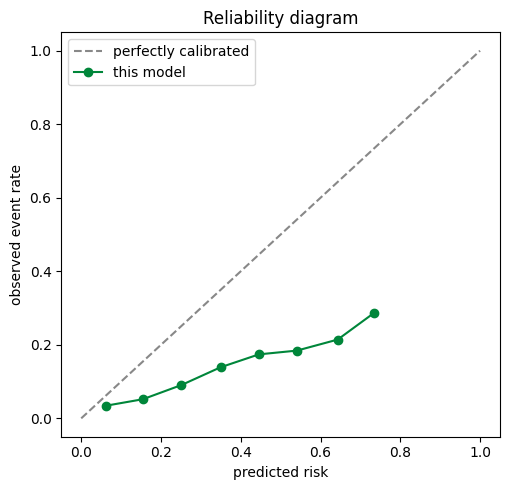

,predicted,observed,n
bucket,,,
"(-0.001, 0.1]",0.063236,0.034574,376
"(0.1, 0.2]",0.154555,0.051991,904
"(0.2, 0.3]",0.250938,0.090472,1249
"(0.3, 0.4]",0.349219,0.138843,1210
"(0.4, 0.5]",0.445557,0.174023,793
"(0.5, 0.6]",0.540917,0.18429,331
"(0.6, 0.7]",0.643087,0.214286,98
"(0.7, 0.8]",0.732918,0.285714,28


In [6]:
import numpy as np

# A reliability diagram: bin by predicted risk, compare to observed rate.
bins = np.linspace(0, 1, 11)
cohort = cohort.assign(bucket=pd.cut(cohort.predicted_risk, bins, include_lowest=True))
rel = (cohort.groupby('bucket', observed=True)
             .agg(predicted=('predicted_risk','mean'),
                  observed=('heat_event_last_summer','mean'),
                  n=('person_id','size'))
             .dropna())

fig, ax = plt.subplots(figsize=(5.2, 5))
ax.plot([0,1],[0,1],'--',color='#888',label='perfectly calibrated')
ax.plot(rel.predicted, rel.observed, 'o-', color='#00863a', label='this model')
ax.set_xlabel('predicted risk'); ax.set_ylabel('observed event rate')
ax.set_title('Reliability diagram'); ax.legend()
plt.tight_layout(); plt.show()

rel

### Fixing it is easy once you have looked

Calibration is a post-hoc transform — you do not need a better model, you need to
have checked. Isotonic regression fits a monotonic mapping from score to probability,
so it **preserves the ranking** while correcting the numbers.

In [7]:
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import train_test_split

tr, te = train_test_split(cohort, test_size=0.4, random_state=42, stratify=cohort.risk_band)
iso = IsotonicRegression(out_of_bounds='clip').fit(tr.predicted_risk, tr.heat_event_last_summer)
te = te.assign(calibrated=iso.predict(te.predicted_risk))

print(f'mean predicted (raw)        : {te.predicted_risk.mean():.3f}')
print(f'mean predicted (calibrated) : {te.calibrated.mean():.3f}')
print(f'actual event rate           : {te.heat_event_last_summer.mean():.3f}')
print()
# ranking preserved?
print('ranking preserved:', (te.sort_values('predicted_risk').calibrated.is_monotonic_increasing))

mean predicted (raw)        : 0.303
mean predicted (calibrated) : 0.111
actual event rate           : 0.118

ranking preserved: True


## Alerts: absence is not evidence of safety

Alerts are Green outside 1 June – 30 September because the season is closed, not
because nobody is at risk. A model trained across the whole year without that
context learns something false.

In [8]:
alerts = ch.tables['alert_history']
print(alerts.groupby('in_alert_season').alert_level.value_counts().unstack(fill_value=0))
print()
print('Longest runs at Amber or above:')
hot = alerts[alerts.alert_level.isin(['Amber','Red'])]
print(hot.nlargest(5, 'consecutive_days_at_level')[['region','alert_date','alert_level','consecutive_days_at_level']].to_string(index=False))

alert_level      Amber  Green  Red  Yellow
in_alert_season                           
False                0  17514    0       0
True               236   7556   37     955

Longest runs at Amber or above:
                  region alert_date alert_level  consecutive_days_at_level
Yorkshire and the Humber 2022-08-21       Amber                          2
         East of England 2021-08-20       Amber                          2
                  London 2019-06-29       Amber                          2
                  London 2023-08-14       Amber                          2
              South East 2019-07-02       Amber                          2


### Why the run length matters

Sustained heat is more dangerous than a single hot day — the risk comes from nights
that do not cool. A row-by-row read cannot see that; `consecutive_days_at_level` and
`temp_min_c` can.

In [9]:
weather = ch.tables['region_weather_daily']
warm_nights = weather[weather.temp_min_c > 18]
print(f'nights above 18C : {len(warm_nights):,} of {len(weather):,}')
print(f'areas most affected: {warm_nights.area.value_counts().head(5).to_dict()}')
print()
print('Every row is synthetic:', bool(weather.is_synthetic.all()))

nights above 18C : 7,597 of 119,802
areas most affected: {'Northamptonshire': 367, 'Northumberland': 347, 'Nottinghamshire': 312, 'Staffordshire': 309, 'Merseyside': 290}

Every row is synthetic: True


## Where to go next

- Join cohort → region → alerts → weather. The grains differ on purpose (alerts are
  regional, weather is county-level), so it is a real join.
- Who is high-risk **and** lives alone **and** is in an area with warm nights?
- Whatever you build must **fail safe**: it supports staff judgement and never
  replaces it. A system that quietly stops flagging is more dangerous than one that
  flags too much.